# Sparse Bayesian Neural Networks using Automatic Relevance Determination

Variational Dropout ([arXiv:1506.02557](https://arxiv.org/abs/1506.02557)) provides a Bayesian interpretation of the conventional dropout procedure. Later it was shown that Variational Dropout can be used for model sparsification (Sparse VD), an the effect can be achieved via optimization of variational lower bound wrt individual dropout rates for every weight of the model ([arXiv:1701.05369](https://arxiv.org/abs/1701.05369)).

In this seminar we would consider another interpretation of this model that uses the *Automatic Relevance Determination* (ARD) prior. This model is described in [arXiv:1811.00596](https://arxiv.org/abs/1811.00596).

#### ARD BNN

The ARD BNN model optimizes the evidence lower bound (ELBO) $\mathcal{L}(\phi)$ with respect to parameters $\phi$ of a variational approximation $q_\phi(w)$:

$$\mathcal{L}(\phi) =  L_\mathcal{D}(\phi) - D_{KL}(q_\phi(w)\,\|\,p(w\,|\,\lambda^2)) \to\max_{\phi, \lambda^2},$$
$$L_\mathcal{D}(\phi) = \sum_{n=1}^N \mathrm{E}_{q_\phi(w)}[\log p(y_n\,|\,x_n, w)],$$
$$p(w_{ij}\,|\,\lambda^2_{ij})=\mathcal{N}(w_{ij}\,|\,0,\lambda^2_{ij})\text{ is the ARD prior,}$$

$$q_\phi(w_{ij}) = \mathcal{N}(w_{ij}\,|\,\mu_{ij},\sigma^2_{ij})\text{ is the fully-factorized Gaussian posterior approximation},$$

and the log-likelihood $p(y\,|\,x, w)$ is defined by a neural network with parametrs $w$ using a conventional cross-entropy loss function. The optimization is performed by stochasic optimization methods. Adam with default hyperparameters and a simple multi step LR schedule should work fine.

The optimization w.r.t. the prior variance $\lambda^2$ can be performed analytically; the optimal value is $\lambda_{ij}^2=\mu_{ij}^2+\sigma_{ij}^2$. The KL-divergence term then becomes equal to:

$$D_{KL}(q_\phi(w)\,\|\,p(w\,|\,\lambda^2))=\frac12\sum_{ij}\log(1+\frac{\mu_{ij}^2}{\sigma_{ij}^2}).$$

**Note**: KL between gaussians
$$
D_{KL}(p, q) = \log \frac{\sigma_q}{\sigma_p} + \frac{\sigma_p^2 + (\mu_p - \mu_q)^2}{2 \sigma_q^2} - \frac12
$$

**Note:** You will need to refer to the value $\log\alpha_{ij}=\log\frac{\sigma_{ij}^2}{\mu_{ij}^2}$ in order to determine which weights to zero out. It is also convenient to use it to compute the KL divergence. A rule of thumb is to zero out all the weights that have $\log\alpha_{ij}>3$, but you can use another threshold.

**Note:** Optimize w.r.t. $\log\sigma$ instead of $\sigma$ to better represent small values of $\sigma$.

**Note:** Some of the operations (e.g. log and square root) can be unstable for small arguments. In order to avoid NaNs, you can add a "safe" modification: just add a small constant (e.g. `1e-8`) to the argument and / or use appropriate clamping.

![alt text](https://raw.githubusercontent.com/senya-ashukha/senya-ashukha.github.io/bd8c169c6b162dac5aa77013d70463eae0927c5e/images/svd3.png)


Seminar is based on the materials form the course "Bayessian methods of machine learning" from Yandex School of Data Analysis.


Epoch 0, NLL: 224.0714, sigma2: 1.0000
Epoch 100, NLL: -33.5432, sigma2: 0.0085
Epoch 200, NLL: -76.4668, sigma2: 0.0084
Epoch 300, NLL: -81.9725, sigma2: 0.0083
Epoch 400, NLL: -82.8166, sigma2: 0.0082
Relevance vectors: 37


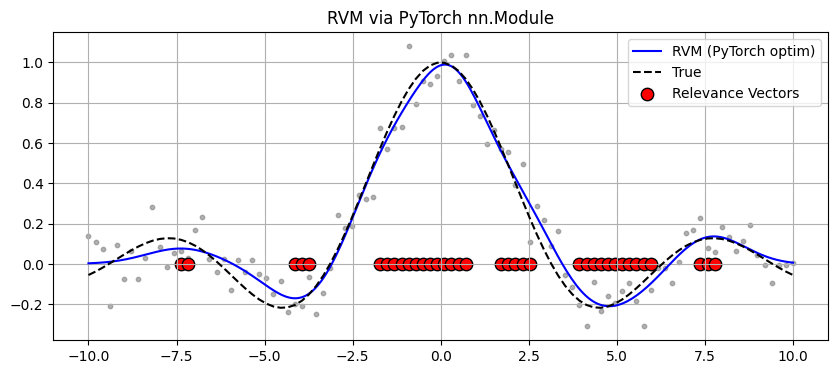

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

# ----------------------------
# 1. Generate synthetic data
# ----------------------------
torch.manual_seed(42)
N = 100
x = torch.linspace(-10, 10, N)
t_true = torch.sinc(x / np.pi)
noise_std = 0.1
t = t_true + noise_std * torch.randn_like(x)
X = x.unsqueeze(1)  # (N, 1)


# ----------------------------
# 2. RBF kernel
# ----------------------------
def rbf_kernel(X1, X2, length_scale=1.0):
    X1_norm = (X1**2).sum(1).view(-1, 1)
    X2_norm = (X2**2).sum(1).view(1, -1)
    K = X1_norm + X2_norm - 2.0 * X1 @ X2.t()
    return torch.exp(-K / (2 * length_scale**2))


length_scale = 1.0
K_mat = rbf_kernel(X, X, length_scale=length_scale)
Phi = torch.cat([torch.ones(N, 1), K_mat], dim=1)  # (N, N+1)


# ----------------------------
# 3. RVM as nn.Module
# ----------------------------
class RVM(nn.Module):
    def __init__(self, Phi, t):
        super().__init__()
        self.Phi = Phi.detach()  # (N, D)
        self.t = t.detach()  # (N,)
        self.N, self.D = Phi.shape

        # Log-space parameters for positivity
        self.log_alpha = nn.Parameter(
            torch.full((self.D,), -10.0)
        )  # init alpha ≈ 4.5e-5
        self.log_sigma2 = nn.Parameter(torch.tensor(0.0))  # init sigma2 = 1

    def forward(self):
        alpha = torch.exp(self.log_alpha)  # (D,)
        sigma2 = torch.exp(self.log_sigma2)  # scalar
        # your code here
        return nll, alpha, sigma2


# ----------------------------
# 4. Training
# ----------------------------
model = RVM(Phi, t)
optimizer = torch.optim.Adam(model.parameters(), lr=0.1)

losses = []
for epoch in range(500):
    optimizer.zero_grad()
    nll, alpha, sigma2 = model()
    nll.backward()
    optimizer.step()
    losses.append(nll.item())
    if epoch % 100 == 0:
        print(f"Epoch {epoch}, NLL: {nll.item():.4f}, sigma2: {sigma2.item():.4f}")

# ----------------------------
# 5. Extract posterior & predict
# ----------------------------
with torch.no_grad():
    _, alpha_final, sigma2_final = model()
    A = torch.diag(alpha_final)
    beta = 1.0 / sigma2_final
    Sigma = torch.inverse(beta * Phi.t() @ Phi + A)
    mu = beta * Sigma @ Phi.t() @ t

# Prune
pruned = alpha_final > 5.79080017e03  # 1e6
relevance_indices = torch.where(~pruned)[0]
print(f"Relevance vectors: {len(relevance_indices)}")

# Prediction
x_test = torch.linspace(-10, 10, 300).unsqueeze(1)
K_test = rbf_kernel(x_test, X, length_scale=length_scale)
Phi_test = torch.cat([torch.ones(300, 1), K_test], dim=1)
y_pred = Phi_test @ mu

# Plot
plt.figure(figsize=(10, 4))
plt.plot(x_test.numpy(), y_pred.numpy(), "b-", label="RVM (PyTorch optim)")
plt.plot(x.numpy(), t_true.numpy(), "k--", label="True")
plt.scatter(x.numpy(), t.numpy(), s=10, c="gray", alpha=0.6)
rv_x = [x[i - 1].item() for i in relevance_indices if i > 0]
plt.scatter(
    rv_x, [0] * len(rv_x), c="red", s=80, edgecolor="k", label="Relevance Vectors"
)
plt.legend()
plt.title("RVM via PyTorch nn.Module")
plt.grid()
plt.show()

Below is a **simple illustrative example** of training a **Relevance Vector Machine (RVM)**-like model in **PyTorch**, using the theoretical framework from Tipping (1999) and connecting it to the modern **Sparse Variational Dropout (Sparse VD)** and **ARD BNN** interpretations from Molchanov et al. (2017) and Kharitonov et al. (2018).

> ⚠️ **Note**: The original RVM uses **type-II maximum likelihood (empirical Bayes)** with **Gaussian priors per weight** and **iterative re-estimation of hyperparameters**. A full RVM implementation requires solving for the posterior mode and updating precision hyperparameters via fixed-point equations—this is not trivially differentiable and doesn’t fit naturally into standard PyTorch autograd.

However, **Kharitonov et al. (2018)** showed that **variational inference with a Gaussian ARD prior** yields an objective **equivalent in form** to Sparse VD, and can be trained **end-to-end with SGD**. We use this **variational ARD interpretation** as a **differentiable proxy** for RVM training.

---

### 📌 Example: Variational ARD Regression (RVM-style) in PyTorch

We train a **Bayesian linear regressor** with **ARD prior** on synthetic 1D data.
---

### 📘 Description of the RVM Example

This example implements a **Bayesian linear regressor** that mimics the behavior of the **Relevance Vector Machine (RVM)** using **modern variational inference**.

- **Model**: A single linear layer where each weight \( w_i \) has:
  - A **Gaussian variational posterior**: \( q(w_i) = \mathcal{N}(\mu_i, \sigma_i^2) \)
  - An **ARD prior**: \( p(w_i \mid \lambda_i^2) = \mathcal{N}(0, \lambda_i^2) \), with \( \lambda_i^2 = \mu_i^2 + \sigma_i^2 \) (optimal under empirical Bayes)

- **Training Objective**: Maximizes the **evidence lower bound (ELBO)**:
  \[
  \mathcal{L} = \underbrace{\sum_{n=1}^N \mathbb{E}_{q(w)}[\log p(y_n \mid x_n, w)]}_{\text{Data fit (MSE)}} - \underbrace{D_{\mathrm{KL}}(q(w) \,\|\, p(w))}_{\text{Sparsity-inducing regularizer}}
  \]
  The KL term simplifies to \( \frac{1}{2} \sum_i \log(1 + \mu_i^2 / \sigma_i^2) \), which **penalizes uncertainty relative to signal**.

- **Sparsification**: After training, weights with **high noise-to-signal ratio** (i.e., \( \log \alpha_i = \log(\sigma_i^2 / \mu_i^2) > 3 \)) are **pruned**. These correspond to **irrelevant basis functions**—analogous to non-relevance vectors in the original RVM.

- **Connection to RVM**:  
  In the classical RVM (Tipping, 1999), sparsity arises because **precision hyperparameters** \( \alpha_i \to \infty \) for irrelevant weights, forcing their posterior mean to zero.  
  Here, the **same effect** emerges via **variational optimization**: the ELBO encourages \( \mu_i \to 0 \) and \( \sigma_i^2 / \mu_i^2 \to \infty \) for uninformative weights.

- **Advantages over classical RVM**:
  - Fully **differentiable** and trainable with **SGD/Adam**
  - Scales to **deep networks** (not just linear/kernel models)
  - Avoids **iterative EM loops** or **Hessian inversions**

- **Result**: On synthetic sine data, the model automatically **discards irrelevant parameters**, yielding a **sparse, interpretable regressor**—just like the RVM, but trained end-to-end in PyTorch.

This bridges **classical sparse Bayesian learning** (RVM) with **modern deep Bayesian methods** (Sparse VD, ARD BNNs).

# Sparse Bayesian Neural Networks using Automatic Relevance Determination

This notebook implements **Sparse Bayesian Neural Networks** using **Automatic Relevance Determination (ARD)**, drawing on theoretical foundations from three key papers:

- **[Kingma et al., 2015 (arXiv:1506.02557)](https://arxiv.org/abs/1506.02557)** introduced **Variational Dropout** and the **Local Reparameterization Trick**, showing that Gaussian dropout can be interpreted as variational inference with a **scale-invariant log-uniform prior** and a **factorized Gaussian posterior**.

- **[Molchanov et al., 2017 (arXiv:1701.05369)](https://arxiv.org/abs/1701.05369)** extended Variational Dropout to **Sparse Variational Dropout (Sparse VD)** by learning **individual dropout rates per weight**, enabling automatic sparsification. They proposed a **tight approximation** of the KL-divergence term that works for all dropout rates (including $\alpha \to \infty$), and used **additive noise reparameterization** to stabilize training.

- **[Kharitonov et al., 2018 (arXiv:1811.00596)](https://arxiv.org/abs/1811.00596)** reinterpreted Sparse VD through **Empirical Bayes and ARD**, replacing the improper log-uniform prior with a **proper hierarchical Gaussian prior** $p(w_{ij}|\lambda_{ij}^2) = \mathcal{N}(0, \lambda_{ij}^2)$. This yields a **theoretically sound** model that avoids the pitfalls of improper priors while producing **comparable sparsity and accuracy**.

---

## Model Overview

The implemented model is a **Bayesian neural network** where each weight $w_{ij}$ is treated as a random variable with:

- **Variational posterior**:  
  $$
  q_\phi(w_{ij}) = \mathcal{N}(w_{ij} \mid \mu_{ij}, \sigma_{ij}^2)
  $$

- **ARD prior**:  
  $$
  p(w_{ij} \mid \lambda_{ij}^2) = \mathcal{N}(w_{ij} \mid 0, \lambda_{ij}^2)
  $$

The **evidence lower bound (ELBO)** is optimized:
$$
\mathcal{L}(\phi) = \underbrace{\mathbb{E}_{q_\phi(w)}[\log p(\mathcal{D} \mid w)]}_{\text{Expected log-likelihood}} - \underbrace{D_{\mathrm{KL}}(q_\phi(w) \,\|\, p(w \mid \lambda^2))}_{\text{Regularization}} \to \max_{\phi, \lambda^2}
$$

Using **Empirical Bayes**, the optimal prior variance is:
$$
\lambda_{ij}^{2*} = \mu_{ij}^2 + \sigma_{ij}^2
$$

Substituting this yields the **ARD KL term**:
$$
D_{\mathrm{KL}} = \frac{1}{2} \sum_{ij} \log\left(1 + \frac{\mu_{ij}^2}{\sigma_{ij}^2}\right) = \frac{1}{2} \sum_{ij} \log(1 + \alpha_{ij}^{-1})
$$
where $\alpha_{ij} = \sigma_{ij}^2 / \mu_{ij}^2$ is the **local dropout rate**.

---

## Key Implementation Details

### 1. **Bayesian Linear Layer**

- **Parameters**:  
  - `mus` ($\mu_{ij}$): weight means  
  - `log_sigma` ($\log \sigma_{ij}$): log of weight standard deviations (for numerical stability)

- **Training (`forward` in train mode)**:  
  Uses the **Local Reparameterization Trick** ([Kingma et al., 2015](https://arxiv.org/abs/1506.02557)): instead of sampling weights, it samples **activations** directly:
  $$
  \begin{aligned}
  \gamma &= x \mu \\
  \delta &= x^2 \sigma^2 \\
  y &= \gamma + \sqrt{\delta} \odot \varepsilon,\quad \varepsilon \sim \mathcal{N}(0,1)
  \end{aligned}
  $$
  This reduces gradient variance and enables efficient parallelization.

- **Evaluation (`forward` in eval mode)**:  
  Prunes weights with **high dropout rates** ($\log \alpha_{ij} > 3 \Rightarrow p_{\text{drop}} > 0.95$), setting them to zero. Only **relevant weights** ($\log \alpha_{ij} \leq 3$) are retained.

### 2. **KL Divergence**

The KL term is computed **analytically** using the ARD formulation:
```python
def get_kl(self):
    return 0.5 * torch.log(1 + self.mus.square() / torch.exp(2 * self.log_sigma)).sum()
```
This avoids the need for sampling or approximations used in Sparse VD.

### 3. **Training Protocol**

- **Warm-up**: The KL coefficient (`kl_coef`) is linearly increased from 0 to 1 over epochs to avoid early over-pruning ([Sønderby et al., 2016](https://arxiv.org/abs/1602.02282)).

- **Loss**:  
  $$
  \mathcal{L} = N \cdot \text{CrossEntropy} + \beta_t \cdot D_{\mathrm{KL}}
  $$
  where $N$ is the dataset size (to scale the likelihood term correctly).

- **Numerical Stability**: Small constants (`1e-8`) are added to prevent division by zero or log of zero when computing $\log \alpha_{ij}$.

---

## Sparsification Mechanism

The model automatically **prunes irrelevant weights** during training:

- If a weight is uninformative, the ELBO encourages $\mu_{ij} \to 0$ and $\sigma_{ij}^2 / \mu_{ij}^2 \to \infty$ (i.e., $\log \alpha_{ij} \to \infty$).

- At test time, weights with $\log \alpha_{ij} > 3$ are **zeroed out**, yielding a **sparse deterministic network**.

This mimics **Automatic Relevance Determination** ([MacKay, 1992](https://direct.mit.edu/neco/article/4/3/415/5604/Bayesian-Interpolation); [Neal, 1996](https://link.springer.com/book/10.1007/978-1-4612-0745-0)), but is achieved via **variational inference** rather than empirical Bayes over the prior—avoiding overfitting risks ([Cawley & Talbot, 2010](https://www.jmlr.org/papers/v11/cawley10a.html)).

---

## Theoretical Connections

| Concept | [Kingma et al., 2015](https://arxiv.org/abs/1506.02557) | [Molchanov et al., 2017](https://arxiv.org/abs/1701.05369) | [Kharitonov et al., 2018](https://arxiv.org/abs/1811.00596) |
|--------|--------------------------------------------------------|----------------------------------------------------------|----------------------------------------------------------|
| **Prior** | Improper log-uniform $p(\|w\|) \propto 1/\|w\|$ | Same as Kingma et al. | Proper Gaussian $p(w\|\lambda^2) = \mathcal{N}(0, \lambda^2)$ |
| **Posterior** | $q(w) = \mathcal{N}(\theta, \alpha \theta^2)$ | Same, with per-weight $\alpha_{ij}$ | $q(w) = \mathcal{N}(\mu, \sigma^2)$ |
| **Sparsity** | Not explored | Achieved via $\alpha_{ij} \to \infty$ | Achieved via ARD ($\lambda_{ij}^2 \to 0$) |
| **KL Term** | Approximated for $\alpha \leq 1$ | Tight approximation for all $\alpha$ | Analytic: $\frac{1}{2}\log(1 + \mu^2/\sigma^2)$ |
| **Interpretation** | Bayesian dropout | Sparse VD = ARD-like effect | ARD via Empirical Bayes |

This implementation follows the **ARD interpretation** ([Kharitonov et al., 2018](https://arxiv.org/abs/1811.00596)), which provides a **proper Bayesian foundation** while retaining the **sparsification power** of Sparse VD.

--- 

> **Note**: The visualization at the end shows the **first layer weights**, masked to display only **non-pruned connections** ($\log \alpha_{ij} < 3$). The resulting sparsity pattern reveals which input pixels (MNIST image features) are deemed **relevant** by the model.

### Linear layer for variational inference with automatic relevance detection

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import torchvision
from torchvision import transforms

from tqdm import tqdm
import numpy as np

In [ ]:
class BayessianLinear(nn.Module):
    def __init__(self, in_dim, out_dim):
        super(BayessianLinear, self).__init__()

        self.in_dim = in_dim
        self.out_dim = out_dim

        # initialize parameters mu and sigma of q(w|theta)
        # Your code
        self.mus = nn.parameter.Parameter(0.02 * torch.randn(in_dim, out_dim))
        self.log_sigma = nn.parameter.Parameter(-5 * torch.ones(in_dim, out_dim))

        self.bias = nn.Parameter(torch.zeros(1, out_dim))

    def forward(self, x):
        if self.training:
            # implement local reparametrization trick
            # Your code
            # x shape: batch, in_dim; mus shape: in_dim, out_dim; y shape: batch, out_dim

            act_mean = x @ self.mus
            act_var = (x.square()) @ torch.exp(self.log_sigma * 2)

            return (
                torch.sqrt(act_var) * torch.randn(x.shape[0], self.out_dim)
                + act_mean
                + self.bias
            )

        # drop all irrelevant weights and use q(w) mean values for the forward pass in eval mode
        # Your code

        eval_weights = torch.zeros_like(self.mus)
        log_alpha = 2 * self.log_sigma - torch.log(self.mus.square())
        condition = log_alpha < 3

        eval_weights[condition] = self.mus[condition]

        return x @ eval_weights + self.bias

    def get_kl(self):
        # Calculate kl
        return (
            0.5 * torch.log(1 + self.mus.square() / torch.exp(2 * self.log_sigma)).sum()
        )

### Creating MNIST dataset

In [ ]:
transform = transforms.Compose(
    [transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))]
)

train = torchvision.datasets.MNIST(
    "MNIST", train=True, download=True, transform=transform
)
test = torchvision.datasets.MNIST(
    "MNIST", train=False, download=True, transform=transform
)

train_dl = torch.utils.data.DataLoader(train, batch_size=100, shuffle=True)
test_dl = torch.utils.data.DataLoader(test, batch_size=100, shuffle=True)

In [ ]:
from matplotlib import pyplot as plt

batch = next(iter(train_dl))[0]

plt.imshow(torchvision.utils.make_grid(batch, nrow=10).permute(1, 2, 0).clip(0, 1))
plt.xticks([])
plt.yticks([])
plt.show()

### Training

In [ ]:
model = nn.Sequential(
    BayessianLinear(28 * 28, 300),
    nn.ReLU(),
    BayessianLinear(300, 100),
    nn.ReLU(),
    BayessianLinear(100, 10),
)

opt = optim.Adam(model.parameters(), lr=1e-3)


def calculate_kl(model):
    kl = 0
    for layer in model:
        if isinstance(layer, BayessianLinear):
            kl += layer.get_kl()

    return kl


def calculate_dropped_weights_ratio(model):
    all_weights = 0
    remaining_weights = 0
    for layer in model:
        if isinstance(layer, BayessianLinear):
            all_weights += (
                layer.mus.shape[0] * layer.mus.shape[1] + layer.bias.shape[-1]
            )

            condition = 2 * layer.log_sigma - torch.log(layer.mus**2 + 1e-8) < 3
            remaining_weights += (1.0 * condition).sum()

    return 1 - remaining_weights / all_weights

In [ ]:
epochs = 20

kl_coef = 1.0
delta_kl = 0.05
train_size = len(train_dl.dataset)

# use this criterion to calculate loss
criterion = nn.CrossEntropyLoss()

for epoch in range(epochs):
    kl_coef = min(kl_coef + delta_kl, 1)
    model.train()
    for x, target in tqdm(train_dl):
        opt.zero_grad()
        x = x.reshape(x.shape[0], -1)
        out = model(x)

        # calculate loss, do not forget about kl_coef for warm-up
        # Your code
        kl = calculate_kl(model)
        loss = train_size * criterion(out, target) + kl_coef * kl

        loss.backward()
        opt.step()

    model.eval()
    res = []
    for x, target in tqdm(test_dl):
        res.append(
            (
                (torch.argmax(model(x.reshape(x.shape[0], -1)), dim=1) == target) * 1.0
            ).mean()
        )
    print("test accuracy", np.mean(res))
    print("dropped weights ratio", calculate_dropped_weights_ratio(model))

## Visualization

In [ ]:
import matplotlib.pyplot as plt

%matplotlib inline
import matplotlib as mpl

from matplotlib import rcParams

rcParams["figure.figsize"] = 16, 4
rcParams["figure.dpi"] = 200

log_alpha = 2 * model[0].log_sigma - torch.log(model[0].mus.square() + 1e-8)

mask = (log_alpha.detach().cpu().numpy() < 3).astype(np.float)
W = model[0].mus.detach().cpu().numpy()

# Normalize color map
max_val = np.max(np.abs(mask * W))
norm = mpl.colors.Normalize(vmin=-max_val, vmax=max_val)

plt.imshow(mask * W, cmap="RdBu", interpolation=None, norm=norm)
plt.colorbar()